In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd

np.random.seed(42)
torch.manual_seed(42)

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

device

device(type='mps')

In [3]:
data_file = '../../output/ensemble/afterRepair/ensemble_results.xlsx'

# Load the data from the Excel file
df = pd.read_excel(data_file, sheet_name=None)
dfs = []
sheet_names = list(df.keys())

for i, sheet in enumerate(sheet_names):
    if i >= 5:  # Process first 5 sheets (indices 0, 1, 2, 3, 4)
        break
    print(f"Processing sheet {i+1}: {sheet}")
    df_sheet = pd.read_excel(data_file, sheet_name=sheet)
    dfs.append(df_sheet)

# Concatenate all dataframes into one
df = pd.concat(dfs, ignore_index=True)
df = df.iloc[:, 3:18]

print(df.columns)
# print number of rows and columns
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")

Processing sheet 1: gpt-4o
Processing sheet 2: gpt-4-turbo
Processing sheet 3: claude_3_opus
Processing sheet 4: gemini-1.5-pro
Processing sheet 5: qwen-coder-plus
Index(['y', 'y_gpt-4-turbo', 'y_gpt-4o-mini', 'y_gpt-4o', 'y_claude_3_opus',
       'y_claude_3.5_sonnet', 'y_gemini-1.5-flash', 'y_gemini-1.5-pro',
       'y_qwen-coder-plus', 'y_deepseek-chat', 'y_claude_3.5_haiku',
       'y_gemini-2.5-flash', 'y_gemini-2.5-pro', 'y_gpt-4.1',
       'y_gpt-4.1-mini'],
      dtype='object')
Number of rows: 4884, Number of columns: 15


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Shuffle the dataframe and reset index
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check for NaN values
print(f"NaN values in dataset: {df_shuffled.isnull().sum().sum()}")
print(f"NaN values by column:\n{df_shuffled.isnull().sum()}")

# Handle NaN values - replace with median for numerical columns
df_cleaned = df_shuffled.fillna(-1)

# Verify no NaN values remain
print(f"NaN values after cleaning: {df_cleaned.isnull().sum().sum()}")

# First column is Y (binary labels: 0 or 1), rest are X
X = df_cleaned.iloc[:, 1:]
y = df_cleaned.iloc[:, 0].astype(int)  # Ensure binary labels are integers

print(f"\nBinary classification labels:")
print(f"Unique values in y: {sorted(y.unique())}")
print(f"Class distribution: {y.value_counts().sort_index()}")
# Fix the percentage formatting
class_percentages = y.value_counts(normalize=True).sort_index() * 100
print(f"Class distribution (%):")
for idx, pct in class_percentages.items():
    print(f"  Class {idx}: {pct:.2f}%")

# Train-test split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nBefore upsampling:")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training class distribution: {y_train.value_counts().sort_index()}")
print(f"Test class distribution: {y_test.value_counts().sort_index()}")

# Upsample class 0 (minority class) by duplicating samples
print("\n--- Upsampling Class 0 (Minority Class) ---")

# Get class counts before upsampling
class_0_count_before = (y_train == 0).sum()
class_1_count_before = (y_train == 1).sum()
print(f"Before upsampling:")
print(f"  Class 0: {class_0_count_before} samples")
print(f"  Class 1: {class_1_count_before} samples")
print(f"  Imbalance ratio (Class 1 / Class 0): {class_1_count_before / class_0_count_before:.2f}")

# Calculate how many times to duplicate class 0 to balance the dataset
target_class_0_count = class_1_count_before  # Make class 0 equal to class 1
duplication_factor = target_class_0_count // class_0_count_before
remaining_samples = target_class_0_count % class_0_count_before

print(f"\nUpsampling strategy:")
print(f"  Target class 0 count: {target_class_0_count}")
print(f"  Duplication factor: {duplication_factor}")
print(f"  Additional samples needed: {remaining_samples}")

# Get indices for class 0 samples
class_0_indices = y_train[y_train == 0].index

# Create upsampled data
X_train_upsampled = X_train.copy()
y_train_upsampled = y_train.copy()

# Duplicate class 0 samples
for i in range(duplication_factor - 1):  # -1 because original samples are already included
    X_train_upsampled = pd.concat([X_train_upsampled, X_train.loc[class_0_indices]], ignore_index=True)
    y_train_upsampled = pd.concat([y_train_upsampled, y_train.loc[class_0_indices]], ignore_index=True)

# Add remaining samples if needed
if remaining_samples > 0:
    additional_indices = class_0_indices[:remaining_samples]
    X_train_upsampled = pd.concat([X_train_upsampled, X_train.loc[additional_indices]], ignore_index=True)
    y_train_upsampled = pd.concat([y_train_upsampled, y_train.loc[additional_indices]], ignore_index=True)

# Shuffle the upsampled training data
shuffle_indices = np.random.permutation(len(X_train_upsampled))
X_train_upsampled = X_train_upsampled.iloc[shuffle_indices].reset_index(drop=True)
y_train_upsampled = y_train_upsampled.iloc[shuffle_indices].reset_index(drop=True)

# Get class counts after upsampling
class_0_count_after = (y_train_upsampled == 0).sum()
class_1_count_after = (y_train_upsampled == 1).sum()

print(f"\nAfter upsampling:")
print(f"  Class 0: {class_0_count_after} samples")
print(f"  Class 1: {class_1_count_after} samples")
print(f"  Total training samples: {len(y_train_upsampled)}")
print(f"  New class balance ratio (Class 1 / Class 0): {class_1_count_after / class_0_count_after:.2f}")
print(f"  Class 0 percentage: {(class_0_count_after / len(y_train_upsampled)) * 100:.2f}%")
print(f"  Class 1 percentage: {(class_1_count_after / len(y_train_upsampled)) * 100:.2f}%")

# Update the training data to use upsampled version
X_train = X_train_upsampled
y_train = y_train_upsampled

print(f"\nTraining data updated with upsampled class 0 samples.")

# Normalize the upsampled training data and test data
print("\n--- Normalizing Data ---")
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print(f"\nAfter normalization:")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Feature mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"Final training class distribution: {y_train.value_counts().sort_index()}")
print(f"Test class distribution: {y_test.value_counts().sort_index()}")


NaN values in dataset: 1441
NaN values by column:
y                        0
y_gpt-4-turbo          131
y_gpt-4o-mini          235
y_gpt-4o                56
y_claude_3_opus         80
y_claude_3.5_sonnet     62
y_gemini-1.5-flash      37
y_gemini-1.5-pro       107
y_qwen-coder-plus       63
y_deepseek-chat         25
y_claude_3.5_haiku     164
y_gemini-2.5-flash      93
y_gemini-2.5-pro       129
y_gpt-4.1               55
y_gpt-4.1-mini         204
dtype: int64
NaN values after cleaning: 0

Binary classification labels:
Unique values in y: [0, 1]
Class distribution: y
0     371
1    4513
Name: count, dtype: int64
Class distribution (%):
  Class 0: 7.60%
  Class 1: 92.40%

Before upsampling:
Training set shape: (3907, 14)
Test set shape: (977, 14)
Training class distribution: y
0     297
1    3610
Name: count, dtype: int64
Test class distribution: y
0     74
1    903
Name: count, dtype: int64

--- Upsampling Class 0 (Minority Class) ---
Before upsampling:
  Class 0: 297 samples
  Clas

In [5]:
# print a sample of the training data
print("Sample of training data:")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Sample of training data:
   y_gpt-4-turbo  y_gpt-4o-mini  y_gpt-4o  y_claude_3_opus  \
0      -1.973506      -1.667186 -2.270036         0.323438   
1       0.350538       0.421498  0.385450         0.323438   
2       0.350538      -1.667186  0.385450         0.323438   
3       0.350538       0.421498  0.385450         0.323438   
4       0.350538       0.421498  0.385450         0.323438   

   y_claude_3.5_sonnet  y_gemini-1.5-flash  y_gemini-1.5-pro  \
0            -2.676190           -2.755168         -2.250129   
1             0.328801            0.314633          0.338039   
2             0.328801            0.314633          0.338039   
3             0.328801            0.314633          0.338039   
4             0.328801            0.314633          0.338039   

   y_qwen-coder-plus  y_deepseek-chat  y_claude_3.5_haiku  y_gemini-2.5-flash  \
0           0.402508         0.278175           -1.965918           -1.494536   
1           0.402508         0.278175            0.3138

In [6]:
# Create validation split from training data with stratification
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Final training set shape: {X_train_final.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Final training class distribution: {y_train_final.value_counts().sort_index()}")
print(f"Validation class distribution: {y_val.value_counts().sort_index()}")

Final training set shape: (5776, 14)
Validation set shape: (1444, 14)
Test set shape: (977, 14)
Final training class distribution: y
0    2888
1    2888
Name: count, dtype: int64
Validation class distribution: y
0    722
1    722
Name: count, dtype: int64


In [7]:
import torch
import torch.nn as nn

class BinaryClassifierNN(nn.Module):
    def __init__(self, input_size, hidden_sizes=[10, 7, 4], dropout_rate=0.3):
        super(BinaryClassifierNN, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
    
        layers.extend([
            nn.Linear(prev_size, 1),
            nn.Sigmoid()
        ])
        
        self.network = nn.Sequential(*layers)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False

    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

def train_binary_classifier(model, criterion, optimizer, scheduler, X_train, y_train, X_val, y_val, num_epochs=1000):
    model.train()
    
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).to(device)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).to(device)
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    early_stopping = EarlyStopping(patience=50, min_delta=1e-6)
    
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs.squeeze(), y_train_tensor)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        if scheduler is not None:
            scheduler.step()
        
        with torch.no_grad():
            train_predictions = (outputs.squeeze() > 0.5).float()
            train_accuracy = (train_predictions == y_train_tensor).float().mean()
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs.squeeze(), y_val_tensor)
            val_predictions = (val_outputs.squeeze() > 0.5).float()
            val_accuracy = (val_predictions == y_val_tensor).float().mean()
        
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        train_accuracies.append(train_accuracy.item())
        val_accuracies.append(val_accuracy.item())
        
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {loss.item():.6f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss.item():.6f}, Val Acc: {val_accuracy:.4f}')
        
        # Early stopping
        if early_stopping(val_loss, model):
            print(f'Early stopping at epoch {epoch + 1}')
            break
    
    return train_losses, val_losses, train_accuracies, val_accuracies

In [8]:
def evaluate_binary_classifier(model, X_test, y_test):
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).to(device)

    with torch.no_grad():
        outputs = model(X_test_tensor)
        # Binary cross-entropy loss
        loss = nn.BCELoss()(outputs.squeeze(), y_test_tensor)
        print(f'Test Loss: {loss.item():.6f}')
        
        # Get predictions (probabilities and binary predictions)
        probabilities = outputs.squeeze().cpu().numpy()
        predictions = (probabilities > 0.5).astype(int)
        
        # Calculate accuracy
        accuracy = (predictions == y_test.to_numpy()).mean()
        print(f'Test Accuracy: {accuracy:.4f}')
    
    return predictions, probabilities, y_test.to_numpy()

In [9]:
# Initialize the binary classifier model
input_size = X_train_final.shape[1]
model = BinaryClassifierNN(input_size=input_size, hidden_sizes=[256, 128, 64], dropout_rate=0.2).to(device)

# Loss function for binary classification and optimizer with weight decay
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2)

print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Device: {device}")
print(f"Model type: Binary Classifier")

Model parameters: 45,953
Device: mps
Model type: Binary Classifier


In [10]:
# Train the binary classifier
train_losses, val_losses, train_accuracies, val_accuracies = train_binary_classifier(
    model, criterion, optimizer, scheduler, 
    X_train_final, y_train_final, X_val, y_val, 
    num_epochs=1000
)

Epoch [100/1000], Train Loss: 1.069129, Train Acc: 0.7175, Val Loss: 0.893554, Val Acc: 0.7742
Epoch [200/1000], Train Loss: 0.740239, Train Acc: 0.7356, Val Loss: 0.794510, Val Acc: 0.7805
Epoch [300/1000], Train Loss: 0.610961, Train Acc: 0.7417, Val Loss: 0.494333, Val Acc: 0.7812
Epoch [400/1000], Train Loss: 0.517206, Train Acc: 0.7523, Val Loss: 0.482489, Val Acc: 0.7798
Epoch [500/1000], Train Loss: 0.495656, Train Acc: 0.7568, Val Loss: 0.473699, Val Acc: 0.7825
Early stopping at epoch 545


In [11]:
predictions, probabilities, true_labels = evaluate_binary_classifier(model, X_test_scaled, y_test)

Test Loss: 0.942060
Test Accuracy: 0.8710


Binary Classification Performance Metrics:
Accuracy: 0.8710
Precision: 0.9410
Recall: 0.9181
F1-Score: 0.9294
AUC-ROC: 0.5739

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.23      0.30      0.26        74
     Class 1       0.94      0.92      0.93       903

    accuracy                           0.87       977
   macro avg       0.59      0.61      0.59       977
weighted avg       0.89      0.87      0.88       977


Confusion Matrix:
[[ 22  52]
 [ 74 829]]


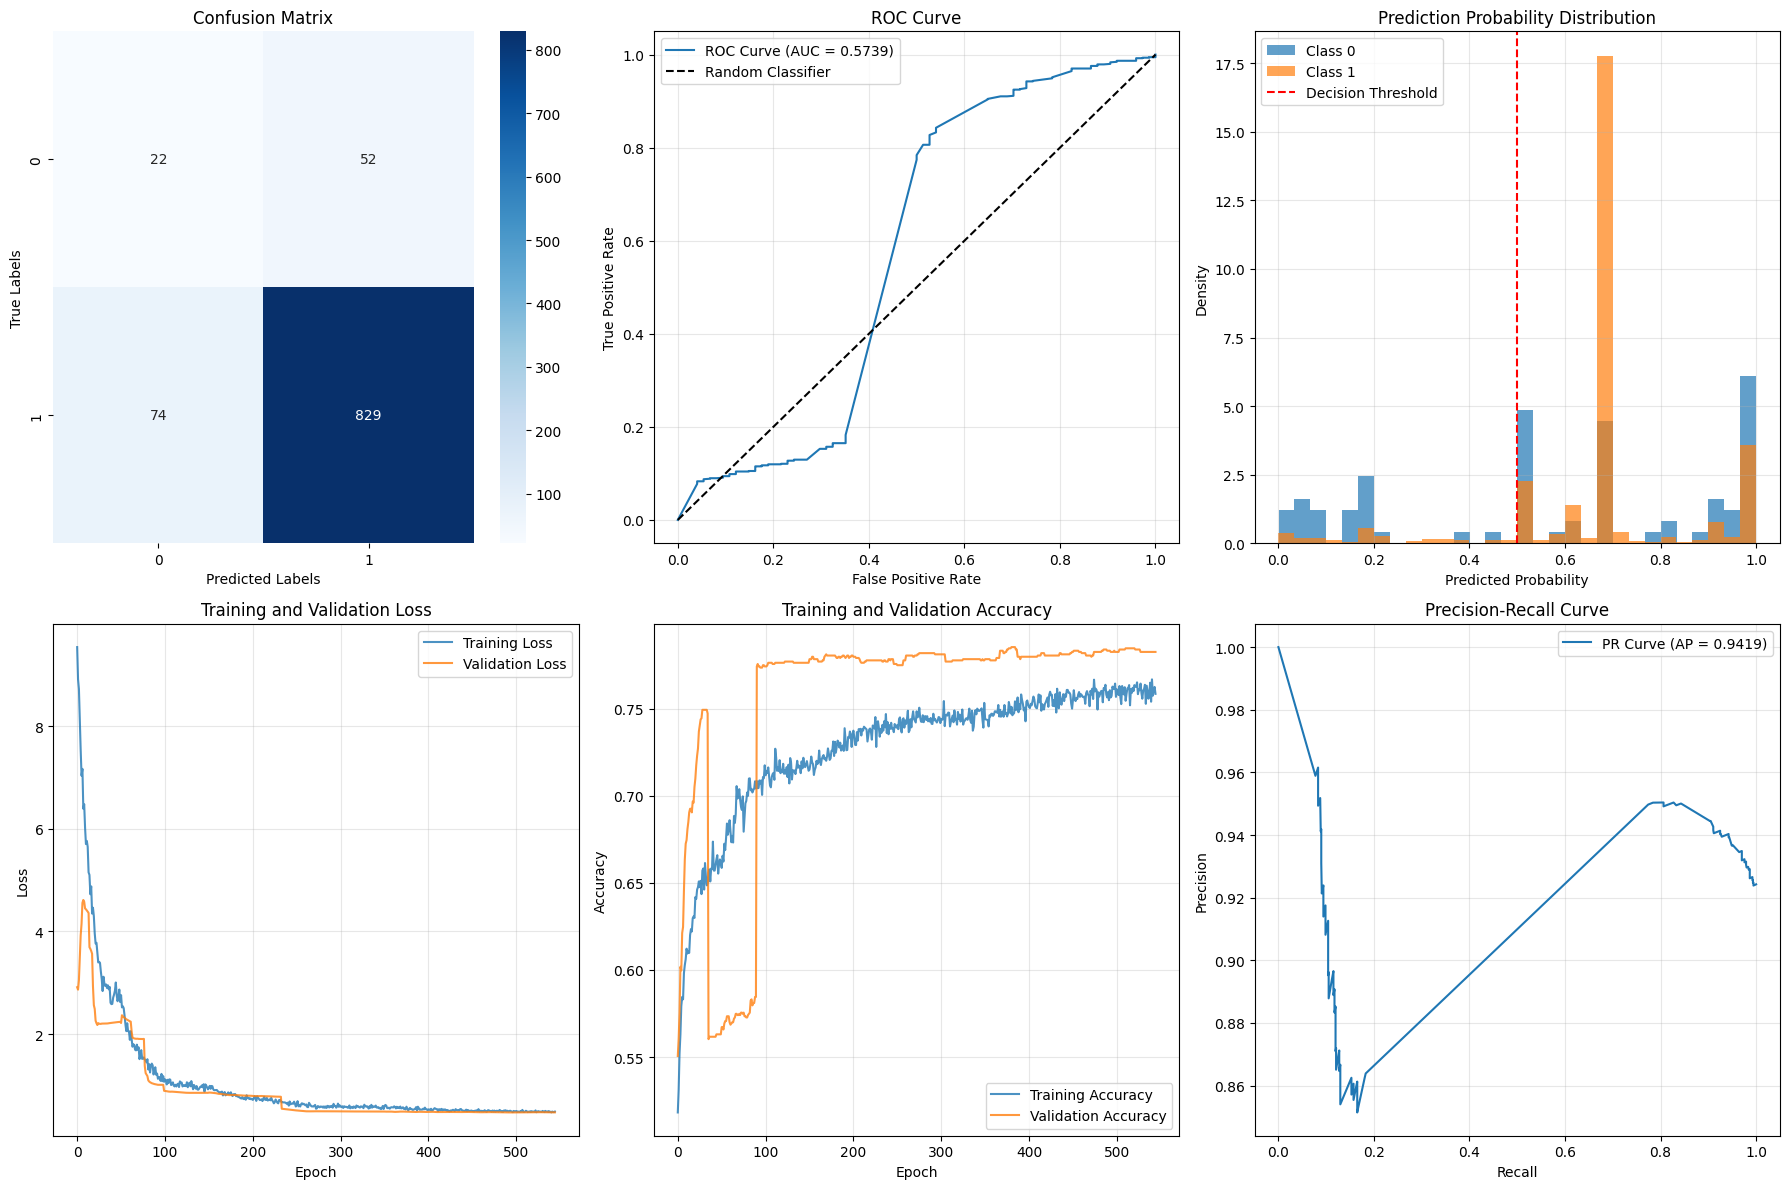

In [12]:
# Comprehensive evaluation metrics for binary classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate classification metrics
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
auc_roc = roc_auc_score(true_labels, probabilities)

print(f'Binary Classification Performance Metrics:')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'AUC-ROC: {auc_roc:.4f}')

print(f'\nDetailed Classification Report:')
print(classification_report(true_labels, predictions, target_names=['Class 0', 'Class 1']))

# Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
print(f'\nConfusion Matrix:')
print(cm)

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_xlabel('Predicted Labels')
axes[0, 0].set_ylabel('True Labels')
axes[0, 0].set_title('Confusion Matrix')

# Plot 2: ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(true_labels, probabilities)
axes[0, 1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_roc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Prediction Probability Distribution
axes[0, 2].hist(probabilities[true_labels == 0], bins=30, alpha=0.7, label='Class 0', density=True)
axes[0, 2].hist(probabilities[true_labels == 1], bins=30, alpha=0.7, label='Class 1', density=True)
axes[0, 2].axvline(x=0.5, color='r', linestyle='--', label='Decision Threshold')
axes[0, 2].set_xlabel('Predicted Probability')
axes[0, 2].set_ylabel('Density')
axes[0, 2].set_title('Prediction Probability Distribution')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Training and Validation Loss
axes[1, 0].plot(train_losses, label='Training Loss', alpha=0.8)
axes[1, 0].plot(val_losses, label='Validation Loss', alpha=0.8)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Training and Validation Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Training and Validation Accuracy
axes[1, 1].plot(train_accuracies, label='Training Accuracy', alpha=0.8)
axes[1, 1].plot(val_accuracies, label='Validation Accuracy', alpha=0.8)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Training and Validation Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score
precision_curve, recall_curve, _ = precision_recall_curve(true_labels, probabilities)
avg_precision = average_precision_score(true_labels, probabilities)
axes[1, 2].plot(recall_curve, precision_curve, label=f'PR Curve (AP = {avg_precision:.4f})')
axes[1, 2].set_xlabel('Recall')
axes[1, 2].set_ylabel('Precision')
axes[1, 2].set_title('Precision-Recall Curve')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Print detailed accuracy information for the binary classifier
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    test_outputs = model(X_test_tensor).cpu().numpy().flatten()

test_predictions = (test_outputs > 0.5).astype(int)
y_test_array = y_test.to_numpy()
test_accuracy = (test_predictions == y_test_array).mean()

print(f"Binary Classifier Performance on Test Set:")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Correct predictions: {(test_predictions == y_test_array).sum()}/{len(y_test)}")
print(f"\nFirst 10 predictions vs actual:")
print(f"Probabilities: {test_outputs[:10]}")
print(f"Predictions:   {test_predictions[:10]}")
print(f"Actual:        {y_test_array[:10]}")

# Class-wise accuracy
class_0_mask = y_test_array == 0
class_1_mask = y_test_array == 1
class_0_accuracy = (test_predictions[class_0_mask] == y_test_array[class_0_mask]).mean()
class_1_accuracy = (test_predictions[class_1_mask] == y_test_array[class_1_mask]).mean()

print(f"\nClass-wise accuracy:")
print(f"Class 0 accuracy: {class_0_accuracy:.4f} ({class_0_accuracy*100:.2f}%)")
print(f"Class 1 accuracy: {class_1_accuracy:.4f} ({class_1_accuracy*100:.2f}%)")

Binary Classifier Performance on Test Set:
Test Accuracy: 0.8710 (87.10%)
Correct predictions: 851/977

First 10 predictions vs actual:
Probabilities: [0.9983834  0.5328596  0.6778338  0.2744736  0.97281724 0.6778338
 0.9999994  0.6778338  0.6778338  0.7822021 ]
Predictions:   [1 1 1 0 1 1 1 1 1 1]
Actual:        [1 1 1 1 0 1 1 1 1 0]

Class-wise accuracy:
Class 0 accuracy: 0.2973 (29.73%)
Class 1 accuracy: 0.9181 (91.81%)


Found 6 sheets: ['gpt-4o', 'gpt-4-turbo', 'claude_3_opus', 'gemini-1.5-pro', 'qwen-coder-plus', 'deepseek-chat']

Evaluating on Sheet: gpt-4o
Sheet data shape: (1012, 15)
Class distribution: y
0     66
1    946
Name: count, dtype: int64
Actual Precision: 946/1012 = 0.9348 (93.48%)
Predicted Precision: 946/1012 = 0.9348 (93.48%)
Model Accuracy: 0.9071 (90.71%)
Confusion Matrix:
[[ 19  47]
 [ 47 899]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.29      0.29      0.29        66
     Class 1       0.95      0.95      0.95       946

    accuracy                           0.91      1012
   macro avg       0.62      0.62      0.62      1012
weighted avg       0.91      0.91      0.91      1012


Evaluating on Sheet: gpt-4-turbo
Sheet data shape: (878, 15)
Class distribution: y
0    113
1    765
Name: count, dtype: int64
Actual Precision: 765/878 = 0.8713 (87.13%)
Predicted Precision: 749/878 = 0.8531 (85.31%)
Model Accuracy: 0.8770 (87.

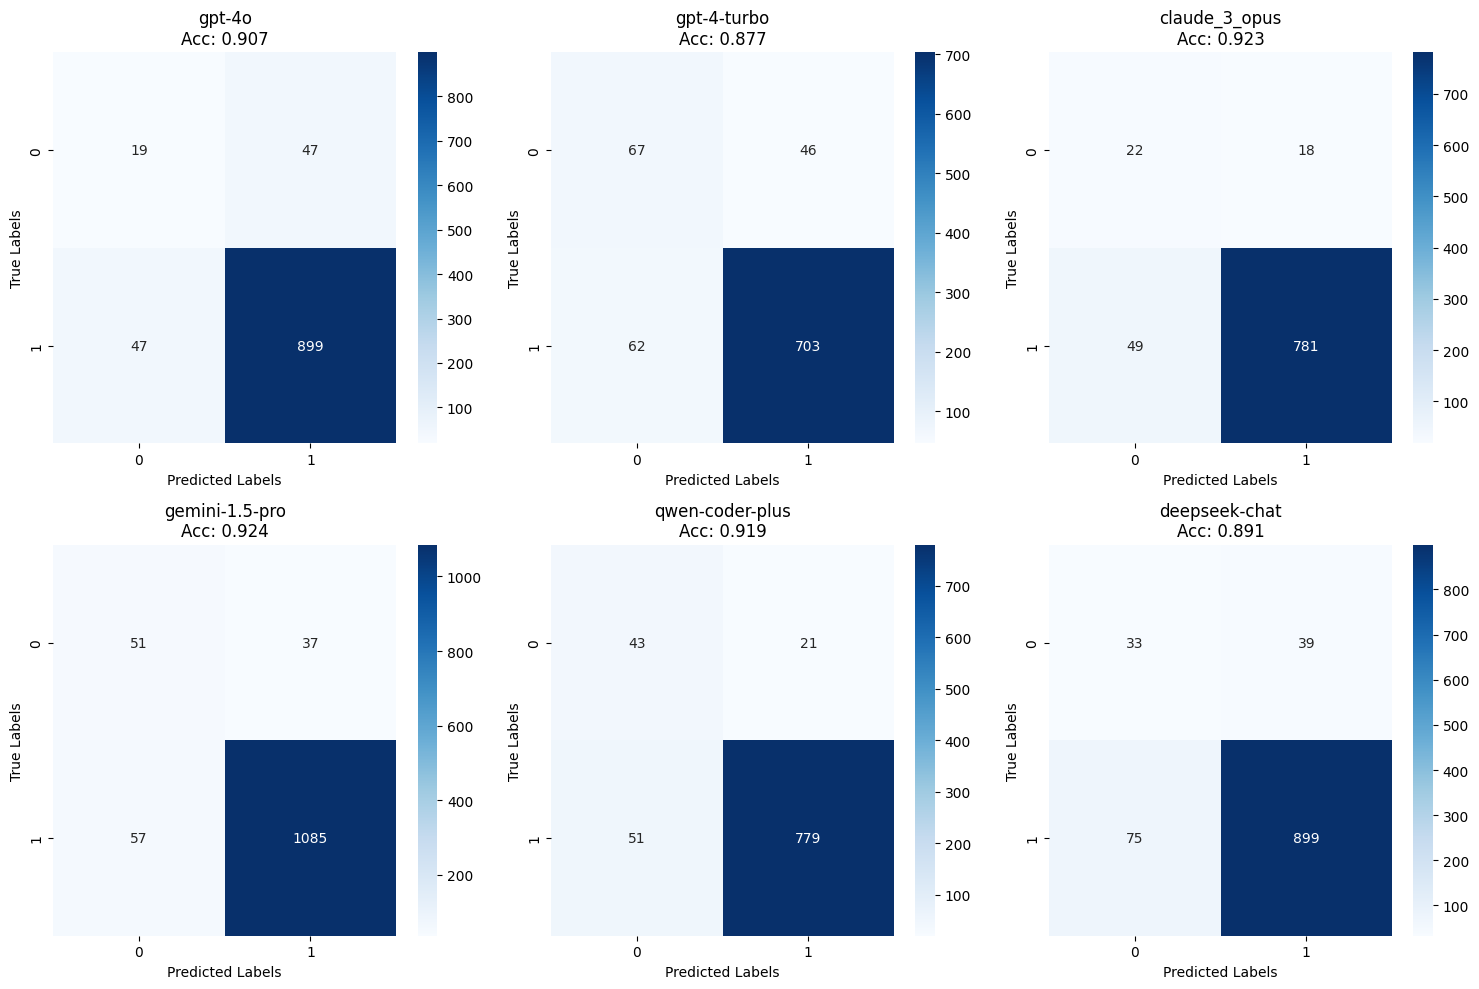


SUMMARY OF RESULTS BY SHEET
Sheet Name                Accuracy   Actual Prec  Pred Prec    Samples  Class 0  Class 1 
--------------------------------------------------------------------------------
gpt-4o                    0.907      0.935        0.935        1012     66       946     
gpt-4-turbo               0.877      0.871        0.853        878      113      765     
claude_3_opus             0.923      0.954        0.918        870      40       830     
gemini-1.5-pro            0.924      0.928        0.912        1230     88       1142    
qwen-coder-plus           0.919      0.928        0.895        894      64       830     
deepseek-chat             0.891      0.931        0.897        1046     72       974     

OVERALL STATISTICS
Average accuracy across sheets: 0.9069 (90.69%)
Average predicted precision across sheets: 0.9017 (90.17%)
Average actual precision across sheets: 0.9247 (92.47%)

Best performing sheet (accuracy): gemini-1.5-pro (0.924)
Worst performing sh

In [14]:
# Evaluate model on each sheet separately and create confusion matrices
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import math

# Load individual sheets again
sheet_data = pd.read_excel(data_file, sheet_name=None)
sheet_names = list(sheet_data.keys())

print(f"Found {len(sheet_names)} sheets: {sheet_names}")

# Calculate grid size for subplots
n_sheets = len(sheet_names)
n_cols = 3  # 3 columns of confusion matrices
n_rows = math.ceil(n_sheets / n_cols)

# Create figure for confusion matrices
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Store results for summary
sheet_results = []

for idx, sheet_name in enumerate(sheet_names):
    print(f"\n{'='*50}")
    print(f"Evaluating on Sheet: {sheet_name}")
    print(f"{'='*50}")
    
    # Load and preprocess sheet data
    sheet_df = sheet_data[sheet_name].iloc[:, 3:18]  # Same column selection as before
    
    # Handle NaN values
    sheet_df_cleaned = sheet_df.fillna(-1)
    
    # Separate features and labels
    X_sheet = sheet_df_cleaned.iloc[:, 1:]
    y_sheet = sheet_df_cleaned.iloc[:, 0].astype(int)
    
    print(f"Sheet data shape: {sheet_df_cleaned.shape}")
    print(f"Class distribution: {y_sheet.value_counts().sort_index()}")
    
    # Calculate actual precision based on your definition
    num_ones_actual = (y_sheet == 1).sum()
    num_zeros_actual = (y_sheet == 0).sum()
    total_actual = num_ones_actual + num_zeros_actual
    actual_precision = num_ones_actual / total_actual if total_actual > 0 else 0
    
    print(f"Actual Precision: {num_ones_actual}/{total_actual} = {actual_precision:.4f} ({actual_precision*100:.2f}%)")
    
    # Check if sheet has both classes
    unique_classes = y_sheet.unique()
    if len(unique_classes) < 2:
        print(f"Warning: Sheet {sheet_name} only has class(es) {unique_classes}. Skipping model evaluation.")
        
        # Create empty plot
        row, col = idx // n_cols, idx % n_cols
        axes[row, col].text(0.5, 0.5, f'Sheet: {sheet_name}\nOnly class {unique_classes[0]}', 
                           ha='center', va='center', transform=axes[row, col].transAxes)
        axes[row, col].set_title(f'{sheet_name}\n(Single class)')
        axes[row, col].axis('off')
        
        sheet_results.append({
            'sheet': sheet_name,
            'accuracy': None,
            'actual_precision': actual_precision,
            'predicted_precision': None,
            'n_samples': len(y_sheet),
            'class_dist': dict(y_sheet.value_counts()),
            'note': 'Single class only'
        })
        continue
    
    # Scale features using the same scaler fitted on training data
    X_sheet_scaled = scaler_X.transform(X_sheet)
    
    # Make predictions
    model.eval()
    with torch.no_grad():
        X_sheet_tensor = torch.tensor(X_sheet_scaled, dtype=torch.float32).to(device)
        sheet_outputs = model(X_sheet_tensor).cpu().numpy().flatten()
    
    sheet_predictions = (sheet_outputs > 0.5).astype(int)
    
    # Calculate predicted precision based on your definition
    num_ones_predicted = (sheet_predictions == 1).sum()
    num_zeros_predicted = (sheet_predictions == 0).sum()
    total_predicted = num_ones_predicted + num_zeros_predicted
    predicted_precision = num_ones_predicted / total_predicted if total_predicted > 0 else 0
    
    print(f"Predicted Precision: {num_ones_predicted}/{total_predicted} = {predicted_precision:.4f} ({predicted_precision*100:.2f}%)")
    
    # Calculate accuracy
    sheet_accuracy = accuracy_score(y_sheet, sheet_predictions)
    
    print(f"Model Accuracy: {sheet_accuracy:.4f} ({sheet_accuracy*100:.2f}%)")
    
    # Create confusion matrix
    cm_sheet = confusion_matrix(y_sheet, sheet_predictions)
    print(f"Confusion Matrix:\n{cm_sheet}")
    
    # Plot confusion matrix
    row, col = idx // n_cols, idx % n_cols
    sns.heatmap(cm_sheet, annot=True, fmt='d', cmap='Blues', ax=axes[row, col])
    axes[row, col].set_xlabel('Predicted Labels')
    axes[row, col].set_ylabel('True Labels')
    axes[row, col].set_title(f'{sheet_name}\nAcc: {sheet_accuracy:.3f}')
    
    # Store results
    sheet_results.append({
        'sheet': sheet_name,
        'accuracy': sheet_accuracy,
        'actual_precision': actual_precision,
        'predicted_precision': predicted_precision,
        'n_samples': len(y_sheet),
        'class_dist': dict(y_sheet.value_counts()),
        'confusion_matrix': cm_sheet
    })
    
    # Print classification report
    print(f"\nClassification Report:")
    print(classification_report(y_sheet, sheet_predictions, target_names=['Class 0', 'Class 1']))

# Hide unused subplots
for idx in range(n_sheets, n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Enhanced summary results with precision information
print(f"\n{'='*80}")
print("SUMMARY OF RESULTS BY SHEET")
print(f"{'='*80}")
print(f"{'Sheet Name':<25} {'Accuracy':<10} {'Actual Prec':<12} {'Pred Prec':<12} {'Samples':<8} {'Class 0':<8} {'Class 1':<8}")
print("-" * 80)

for result in sheet_results:
    class_0 = result['class_dist'].get(0, 0)
    class_1 = result['class_dist'].get(1, 0)
    acc_str = f"{result['accuracy']:.3f}" if result['accuracy'] is not None else "N/A"
    actual_prec_str = f"{result['actual_precision']:.3f}"
    pred_prec_str = f"{result['predicted_precision']:.3f}" if result['predicted_precision'] is not None else "N/A"
    
    print(f"{result['sheet']:<25} {acc_str:<10} {actual_prec_str:<12} {pred_prec_str:<12} {result['n_samples']:<8} {class_0:<8} {class_1:<8}")

# Calculate average metrics (excluding single-class sheets for accuracy and predicted precision)
valid_accuracies = [r['accuracy'] for r in sheet_results if r['accuracy'] is not None]
valid_pred_precisions = [r['predicted_precision'] for r in sheet_results if r['predicted_precision'] is not None]
all_actual_precisions = [r['actual_precision'] for r in sheet_results]

print(f"\n{'='*50}")
print("OVERALL STATISTICS")
print(f"{'='*50}")

if valid_accuracies:
    avg_accuracy = np.mean(valid_accuracies)
    print(f"Average accuracy across sheets: {avg_accuracy:.4f} ({avg_accuracy*100:.2f}%)")

if valid_pred_precisions:
    avg_pred_precision = np.mean(valid_pred_precisions)
    print(f"Average predicted precision across sheets: {avg_pred_precision:.4f} ({avg_pred_precision*100:.2f}%)")

if all_actual_precisions:
    avg_actual_precision = np.mean(all_actual_precisions)
    print(f"Average actual precision across sheets: {avg_actual_precision:.4f} ({avg_actual_precision*100:.2f}%)")

if valid_accuracies:
    best_acc_sheet = max(sheet_results, key=lambda x: x['accuracy'] if x['accuracy'] else 0)
    worst_acc_sheet = min([r for r in sheet_results if r['accuracy'] is not None], key=lambda x: x['accuracy'])
    print(f"\nBest performing sheet (accuracy): {best_acc_sheet['sheet']} ({best_acc_sheet['accuracy']:.3f})")
    print(f"Worst performing sheet (accuracy): {worst_acc_sheet['sheet']} ({worst_acc_sheet['accuracy']:.3f})")

if valid_pred_precisions:
    best_pred_prec_sheet = max([r for r in sheet_results if r['predicted_precision'] is not None], key=lambda x: x['predicted_precision'])
    worst_pred_prec_sheet = min([r for r in sheet_results if r['predicted_precision'] is not None], key=lambda x: x['predicted_precision'])
    print(f"Highest predicted precision sheet: {best_pred_prec_sheet['sheet']} ({best_pred_prec_sheet['predicted_precision']:.3f})")
    print(f"Lowest predicted precision sheet: {worst_pred_prec_sheet['sheet']} ({worst_pred_prec_sheet['predicted_precision']:.3f})")